# Friedel Pair Matching — Demo Notebook

*Written by Jean-Baptiste Jacob, May 2026*

This notebook demonstrates how to find and validate **Friedel pairs** in an ImageD11 columnfile using the `friedel_pairs` module. 

---

### Friedel relationships — geometry on the detector
A Friedel pair is a couple of diffraction peaks related by the centrosymmetry of the diffraction pattern: reflection $(h,k,l)$ and its Friedel mate $(-h,-k,-l)$ produce peaks at predictable mirror positions in detector/reciprocal space. 
A maximum of four Friedel reflections ("entry" and "exit" reflections of $(h,k,l)$ and $(-h,-k,-l)$) occurs during a full 360° rotation of the sample. Finding these pairs is useful for refining diffraction geometry, estimating grain positions, and improving indexing. 


```
                          η = 0°
                            |    
           (ω_0,η_0) p0     |      p2 (ω_3,η_3)      
                       o    |    *
                            |        
                            |       
             η=-90°  -------+------- η = 90°
                            |
                            |    
                       o    |    *
           (ω_1,η_1) p1     |     p2 (ω_2,η_2)              
                            |
                        η = ±180°
```

Two types of Friedel pairs can be exploited, depending on the acquisition (half or ful-360° rotation in omega):

**Omega pairs** — the two twins $p_0$, $p_1$ that appear at omega angles 180° apart:

$\mathbf{g}_1 = -\mathbf{g}_0 \qquad \eta_1 = 180° - \eta_0$

**Eta pairs** — "entry" and "exit" twins $p_0$, $p_2$ at $\omega \pm \theta$:

$\mathbf{g}_2 = -\mathbf{g}_0 \qquad \eta_2 = 180° + \eta_0$

Both types share the same g-vector antisymmetry ($\mathbf{g}_{twin} = -\mathbf{g}_{ref}$) and are matched using a KDTree search in the 5D space $(g_x, g_y, g_z, \eta, \log I)$.

Symmetrically, $p_2$ and $p_3$ form a mirror set of omega-pairs, and $p_1$ and $p_2$ a mirror set of eta-pairs. The set $(p_0,p_1,p_2,p_3)$ forms a full Friedel quadruplet.

### Load data

In [1]:
import os, sys, time
start = time.time()

# python environment stuff
IMAGED11_PATH = '/home/esrf/jean1994b/ImageD11_jbjacob'  # None means do not use git, otherwise enter the name of the folder to use for the git checkout "ImageD11" or "ImageD11_version_xx", etc
CHECKOUT_PATH = 'ImageD11'  # the name of the git checkout folder within path. None means guess

if IMAGED11_PATH is not None:
    if '/data/id11/nanoscope' not in sys.path:
        sys.path.append('/data/id11/nanoscope')
    import install_ImageD11_from_git
    install_ImageD11_from_git.setup_ImageD11_from_git(IMAGED11_PATH,CHECKOUT_PATH)


# Setting path via: 
sys.path.insert(0, /home/esrf/jean1994b/ImageD11_jbjacob/ImageD11 )
# Running from: /home/esrf/jean1994b/ImageD11_jbjacob/ImageD11/ImageD11/__init__.py


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ImageD11.sinograms.dataset
import ImageD11.sinograms.geometry
import ImageD11.friedel_pairs as fp
import logging

logging.basicConfig(level=logging.INFO)

%load_ext autoreload
%autoreload 2
%matplotlib ipympl

In [3]:
# Datasets examples

# WG: Westerly Granite | ~5mmx2.5mm chunk, 50µm voxels, 360° acq. | quartz, feldspars, biotite, Fe-oxides. peaks_2D only
#dset_path = '/data/id11/inhouse2/test_data_3DXRD/S3DXRD/full_360_deg_scans/WG/WG_DT360Z5480/WG_DT360Z5480_dataset.h5'

# C18A_01: metamorphic rock (quartz + garnet) | 1x2mm chunk, 360° acq on central ROI on central ROI (800µm diam.), 7.5 µm voxels. 
dset_path = '/data/id11/inhouse2/test_data_3DXRD/S3DXRD/full_360_deg_scans/C18A_01/C18A_01_z180/C18A_01_z180_dataset.h5'

# FeAu: Iron-gold sample. 180° acquisition
#dset_path = '/data/id11/inhouse2/test_data_3DXRD/S3DXRD/FeAu/PROCESSED_DATA/20250320/tomo_route/FeAu_0p5_tR_nscope/FeAu_0p5_tR_nscope_top_200um/FeAu_0p5_tR_nscope_top_200um_dataset.h5'

# FeAu f2scan: Iron-Gold sample, 360° acquisition with f2scan
#dset_path = '/data/id11/inhouse2/test_data_3DXRD/S3DXRD/FeAu_f2scan/PROCESSED_DATA/20250312_JADB/FeAu_No1_190um/FeAu_No1_190um_2um_redo_z_0/FeAu_No1_190um_2um_redo_z_0_dataset.h5'

In [4]:
ds = ImageD11.sinograms.dataset.load(dset_path)
print(ds)

dataroot = "."
analysisroot = "/data/id11/inhouse2/test_data_3DXRD/S3DXRD/full_360_deg_scans/"
sample = "C18A_01"
dset = "z180"
shape = ( 109, 7220)
# scans 109 from 1.1 to 109.1


In [5]:
#ds.shape = (70,900)
#ds.ybincens = None
#ds.guessbins()
#ds.ybincens.shape

In [5]:
cf_2d = ds.get_cf_2d()
cf_2d.parameters.loadparameters(ds.parfile)
cf_2d.updateGeometry()
print(cf_2d.nrows)

Loading existing colfile from /data/id11/inhouse2/test_data_3DXRD/S3DXRD/full_360_deg_scans/C18A_01/C18A_01_z180/C18A_01_z180_peaks_2d.h5
Reading your columnfile in hdf format


copied an array: size=11918964, elsize=4
copied an array: size=11918964, elsize=4
copied an array: size=11918964, elsize=4


11918964


In [6]:
cf_4d = ds.get_cf_4d()
cf_4d.parameters.loadparameters(ds.parfile)
cf_4d.updateGeometry()
cf_4d.nrows

Loading existing colfile from /data/id11/inhouse2/test_data_3DXRD/S3DXRD/full_360_deg_scans/C18A_01/C18A_01_z180/C18A_01_z180_peaks_4d.h5
Reading your columnfile in hdf format


5744432

### 1 — Global pairing (small peakfiles)

Suitable for **box-beam** datasets or any columnfile small enough (~up to a few million peaks). The full columnfile is split into two mirror halves, the partner half is flipped into the reference frame, and an iterative nearest-neighbour search finds the pairs.

---

#### 1.1 — Set up `FriedelPairIndexer`

Create an indexer object by passing a columnfile and a dataset object. The key tolerance parameters control the maximum allowed mismatch between a candidate pair:

- `tol_gv` — g-vector distance tolerance
- `tol_eta` — eta angle tolerance (degrees)
- `tol_logI` — log_10 intensity tolerance; set to `np.inf` to ignore intensity

An optional `weights` dict lets you emphasise or suppress individual dimensions of the search space. `n_steps` controls how many distance increments are used in the iterative search: more steps = finer resolution. For large peakfiles, increasing n_steps to a large number (>50) can make pairing faster. 

`weights` keys: `gx`, `gy`, `gz`, `eta`, `I`.  Default to 1

In [13]:
# Initiate FriedelPairsIndexer instance with 4d peaks
FPIndexer = fp.FriedelPairIndexer(cf_4d, ds,
                                   tol_gv=0.05,
                                   tol_eta=0.2,
                                   tol_logI=np.inf,
                                   n_steps=10,
                                   weights = {'I':1e-5})

#### 1.2 — Match omega pairs

Call `match_friedel_pairs(pair_type='omega')` to find omega pairs across the full columnfile. Internally this:

1. Sorts the columnfile by omega and splits it into the two 180°-apart halves
2. Runs a **pilot pairing** on a small subset to auto-calibrate the search-space weights
3. Performs the **iterative KDTree search**, applying physical tolerance filters at each step (in `strict` mode) or once at the end (`relaxed` mode)
4. Writes an `omega_pair_id` column to the columnfile (`-1` for unpaired peaks)

Once omega-pairs have been matched, repeat with `pair_type='eta'` to find eta pairs and add an `eta_pair_id` column.

**NOTE**: omega-pairs can only be found in **complete rotation scans** with a full 360-deg acquisition in omega. For half-scans (180° acquisition), setting `pair_type = 'omega'` will raise an error. 


INFO:ImageD11.friedel_pairs.FriedelPairIndexer:--- MATCH FRIEDEL PAIRS [omega pairs] ---
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:--- SEARCH SPACE CALIBRATION [pilot pairing] ---
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  pilot search: cutoff=0.0044  pairs found: 6071
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:Typical (median) pair distances in non-weighted search space:
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  gvecs: 0.0016
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  eta:   0.0017 deg
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  logI:  0.0000
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  Euclidean dist: 0.0033
/home/esrf/jean1994b/ImageD11_jbjacob/ImageD11/ImageD11/friedel_pairs.py:1624: RuntimeWarning: invalid value encountered in scalar multiply
  tol_logI_n = tol_logI * _w['I']
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  Effective weights  : {'gx': '1.000', 'gy': '1.000', 'gz': '1.000', 'eta': '0.974', 'I': '0.000'}
INFO:ImageD11.friedel_pai


--------------------------------------------------
  FRIEDEL PAIR SEARCH  [omega]
--------------------------------------------------
  Subsets    : 2874822 + 2869610 peaks
  Tolerances : gv=0.05  eta=0.2 deg  logI=inf
  dist_max   : 0.2132  (10 steps)

--------------------------------------------------
  ITERATIVE PAIR MATCHING [10 steps]
--------------------------------------------------
  step 1/10  cutoff=0.0213  -> +965620 pairs
  [##########....................] 33.6%  (965620/2869610)
  step 2/10  cutoff=0.0426  -> +622530 pairs
  [################..............] 55.3%  (1588150/2869610)
  step 3/10  cutoff=0.0640  -> +326984 pairs
  [####################..........] 66.7%  (1915134/2869610)
  step 4/10  cutoff=0.0853  -> +203935 pairs
  [######################........] 73.8%  (2119069/2869610)
  step 5/10  cutoff=0.1066  -> +137948 pairs
  [#######################.......] 78.7%  (2257017/2869610)
  step 6/10  cutoff=0.1279  -> +95509 pairs
  [########################......] 82.0

INFO:ImageD11.friedel_pairs.FriedelPairIndexer:--- MERGING OUTPUTS  [omega-pair] ---
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  1 chunk(s) to merge  (5744432 peaks total)
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  2006231 candidate pairs from 1 chunks
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  OK: all pair_ids appear exactly twice
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  2006231 pairs, 4012462 peaks paired (69.8%)
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  86.9% of total intensity matched



--------------------------------------------------



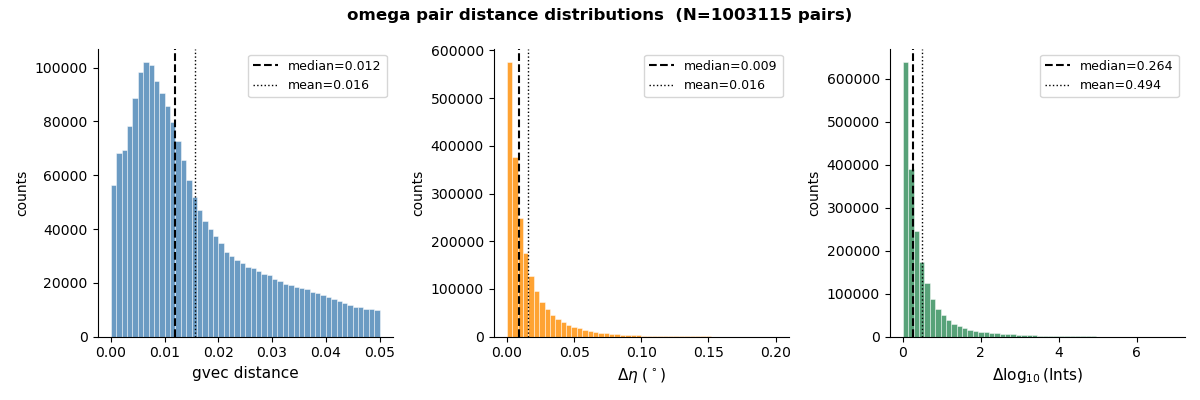

In [14]:
# try omega pairs. should raise error with the default FeAu dataset (180° acquisition)
cf_paired = FPIndexer.match_friedel_pairs(pair_type='omega',
                                          drop_unpaired=False,
                                          filter_mode='relaxed',
                                          doplot=True)


INFO:ImageD11.friedel_pairs.FriedelPairIndexer:--- MATCH FRIEDEL PAIRS [eta pairs] ---
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:--- SEARCH SPACE CALIBRATION [pilot pairing] ---
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  pilot search: cutoff=0.0044  pairs found: 11783
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:Typical (median) pair distances in non-weighted search space:
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  gvecs: 0.0018
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  eta:   0.0017 deg
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  logI:  0.0000
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  Euclidean dist: 0.0036
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  Effective weights  : {'gx': '0.967', 'gy': '0.967', 'gz': '0.967', 'eta': '1.000', 'I': '0.000'}
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  Rescaled dist_max : 0.2168



--------------------------------------------------
  FRIEDEL PAIR SEARCH  [eta]
--------------------------------------------------
  Subsets    : 2889831 + 2854601 peaks
  Tolerances : gv=0.05  eta=0.2 deg  logI=inf
  dist_max   : 0.2168  (10 steps)

--------------------------------------------------
  ITERATIVE PAIR MATCHING [10 steps]
--------------------------------------------------
  step 1/10  cutoff=0.0217  -> +743420 pairs
  [#######.......................] 26.0%  (743420/2854601)
  step 2/10  cutoff=0.0434  -> +443925 pairs
  [############..................] 41.6%  (1187345/2854601)
  step 3/10  cutoff=0.0650  -> +331719 pairs
  [###############...............] 53.2%  (1519064/2854601)
  step 4/10  cutoff=0.0867  -> +241112 pairs
  [##################............] 61.7%  (1760176/2854601)
  step 5/10  cutoff=0.1084  -> +167368 pairs
  [####################..........] 67.5%  (1927544/2854601)
  step 6/10  cutoff=0.1301  -> +114609 pairs
  [#####################.........] 71.5%

INFO:ImageD11.friedel_pairs.FriedelPairIndexer:--- MERGING OUTPUTS  [eta-pair] ---
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  1 chunk(s) to merge  (5744432 peaks total)


Applying final tolerance filters
Total pairs after filtering : 1506051 / 2854601
  [###############...............] 52.8%  (1506051/2854601)

--------------------------------------------------



INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  1506051 candidate pairs from 1 chunks
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  OK: all pair_ids appear exactly twice
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  1506051 pairs, 3012102 peaks paired (52.4%)
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  74.1% of total intensity matched


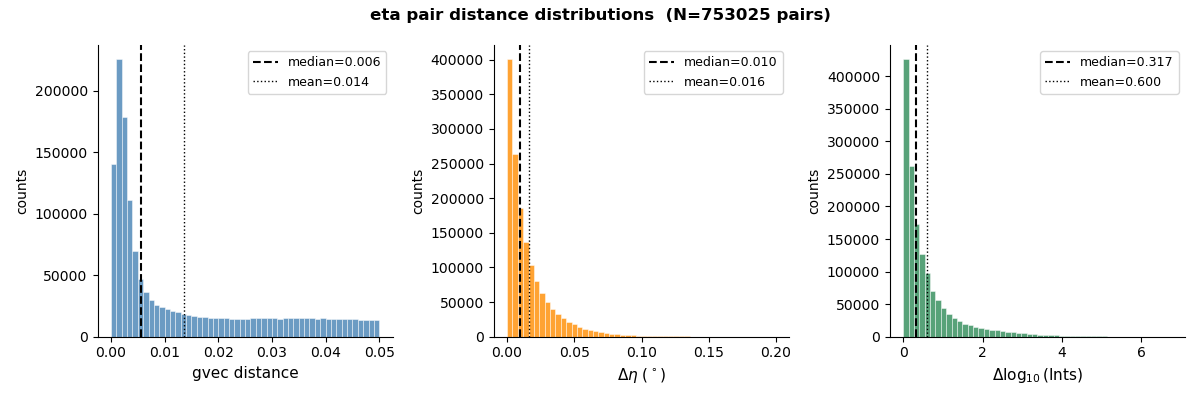

In [15]:
# match eta pairs
cf_paired = FPIndexer.match_friedel_pairs(pair_type='eta',
                                          drop_unpaired=False,
                                          filter_mode='relaxed',
                                          doplot=True,
                                          timeout= 120)

### 1.3 — Evaluate pair distances

Setting `doplot = True` plots the distributions of physical distances between matched pairs along each search dimension: g-vector norm, Δη, and Δlog_10(I). Well-matched pairs should cluster tightly near zero. Broad or skewed distributions suggest the tolerances may need adjusting or the geometry calibration could be improved.

These plots can also can be displayed a posteriori with `plot_pair_distances(cf, pair_type)` 

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: xlabel='gvec distance', ylabel='counts'>,
        <Axes: xlabel='$\\Delta\\eta$ ($^\\circ$)', ylabel='counts'>,
        <Axes: xlabel='$\\Delta \\log_{10}(\\rm{Ints})$', ylabel='counts'>],
       dtype=object))

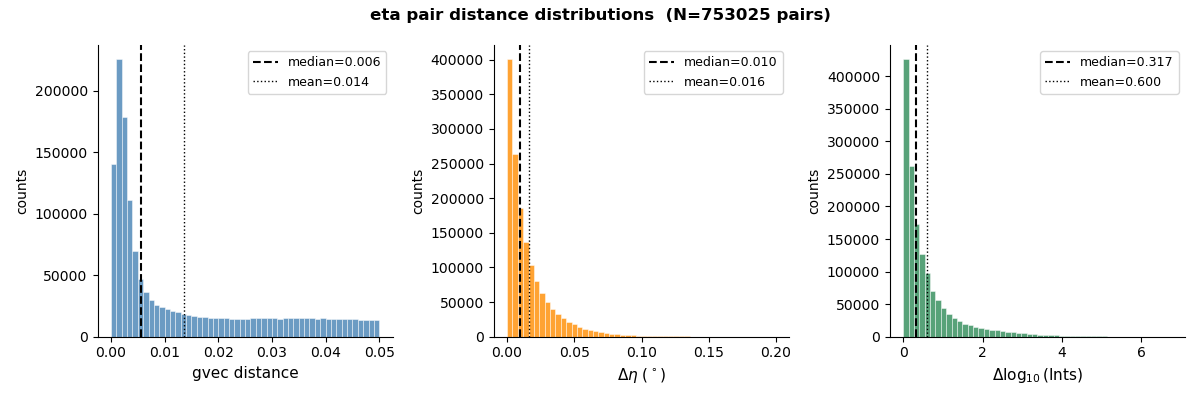

In [16]:
fp.plot_pair_distances(cf_paired, pair_type='eta')

`get_pair_distances(cf, pair_type='omega')` returns the raw distances (dict) and corresponding tuple of indices (idx1,idx2) for the two paired subsets. 

`get_pairs(cf, pair_type)` returns the indices tuple only.

In [17]:
# get pair distances and indices
dist, (idx1, idx2) = fp.get_pair_distances(cf_paired, 'eta')
dist

{'d_gv': array([0.00902118, 0.00074716, 0.03756064, ..., 0.01042416, 0.01935604,
        0.0064205 ]),
 'd_eta': array([0.01027024, 0.00068474, 0.02842747, ..., 0.01440771, 0.03190748,
        0.0127285 ]),
 'd_logI': array([0.09691001, 0.66900678, 2.02256583, ..., 0.19629465, 0.23608919,
        0.1383027 ])}

Text(0, 0.5, 'counts')

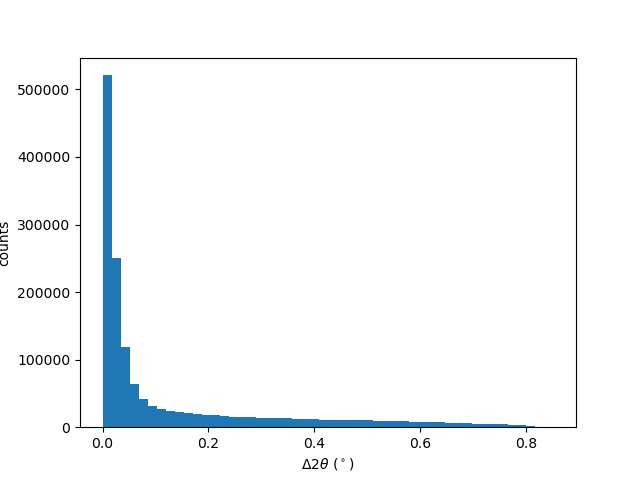

In [18]:
#plot d_tth = |tth2 - tth1|
idx1, idx2 = fp.get_pairs(cf_paired, 'eta')
dtth = np.abs(cf_paired.tth[idx2] - cf_paired.tth[idx1])

plt.figure()
plt.hist(dtth, 50);
plt.xlabel('$\\Delta 2\\theta$ ($^\\circ$)')
plt.ylabel('counts')

#### 1.4 — Relocate pairs in the sample

Once omega and eta-pairs have been identified, both can be used to relocate the diffraction source $(x_s,y_s)$ in the sample with `locate_omega_pairs` and `locate_eta_pairs`.

**Eta-pairs:** paired reflections arising from the same spot are observed at different omega angles and dty positions. The dty–omega relationship:

$\text{dty} - y_0 = -x_s \sin(\omega) - y_s \cos(\omega)$

yields a 2×2 linear system per pair:

$\begin{pmatrix} -\sin(\omega_1) & -\cos(\omega_1) \\ -\sin(\omega_2) & -\cos(\omega_2) \end{pmatrix} \begin{pmatrix} x_s \\ y_s \end{pmatrix} = \begin{pmatrix} \text{dty}_1 - y_0 \\ \text{dty}_2 - y_0 \end{pmatrix}$

which is solved directly.

**Omega-pairs:** the two reflections are observed ~180° apart in omega, making the matrix above near-singular. Instead, the offset $d_x$ along the beam axis is derived from the two-theta asymmetry:

$$d_x = L . \frac{\tan(2\theta_1) - \tan(2\theta_2)}{\tan(2\theta_1) + \tan(2\theta_2)}$$

Then, the lab-frame coordinates $(d_x, \text{dty} - y_0)$ are rotated back into the sample frame.

In [19]:
# get pairs
i1, i2 = fp.get_pairs(cf_paired, 'omega')
i1_, i2_ = fp.get_pairs(cf_paired, 'eta')

# sample coordinates. y0_guess from fit_y0 notebook
y0_guess = 0 
xs, ys = fp.locate_omega_pairs(cf_paired, (i1,i2), ds, y0=y0_guess)
xs_, ys_ = fp.locate_eta_pairs(cf_paired, (i1_,i2_), ds, y0=y0_guess)

`locate_omega_pairs` and `locate_eta_pairs` add sample coordinates to cf as new columns. The last function call overwrites the previous one. 

Now we can get a diffraction image of the sample, by plotting a 2D histogram of peaks in (xs,ys) space.

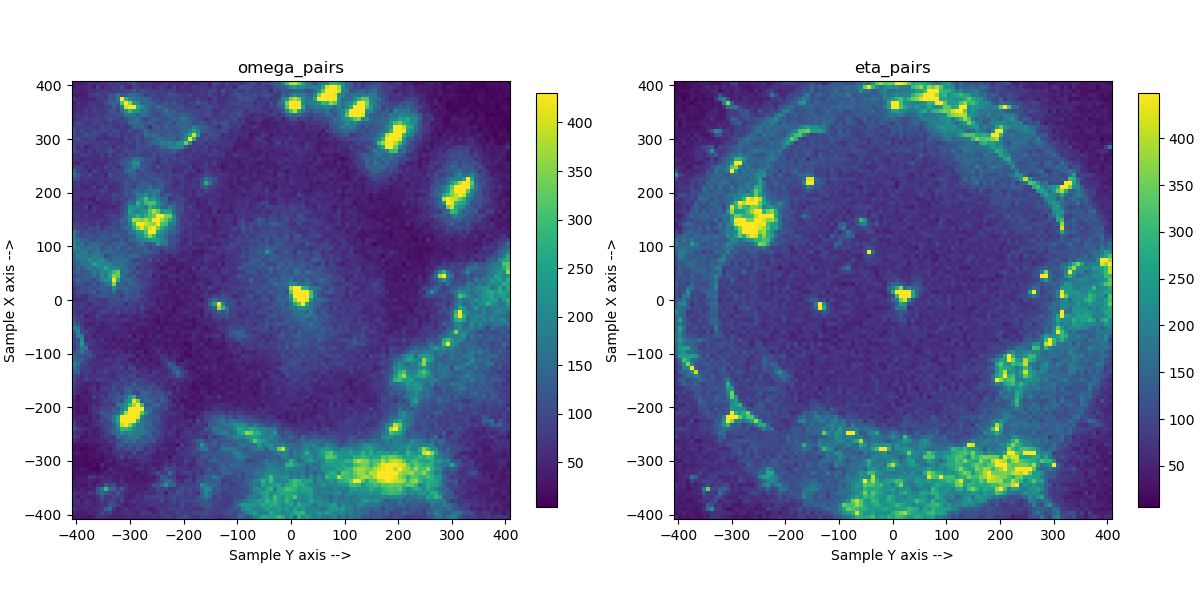

In [20]:
# histogram values
hist_guess = np.histogram2d(xs, ys, bins=ds.ybinedges)[0]
hist_guess_ = np.histogram2d(xs_, ys_, bins=ds.ybinedges)[0]

# plot for omega and eta hist
fig, ax = plt.subplots(1,2,layout='constrained', figsize=(12,6))
im0 = ax[0].pcolormesh(ds.ybinedges, ds.ybinedges, hist_guess, vmax=np.percentile(hist_guess.flatten(),99))
ax[0].set_aspect(1)
ax[0].set(title=f'omega_pairs', xlabel='Sample Y axis -->', ylabel='Sample X axis -->')
plt.colorbar(im0, ax=ax[0], orientation='vertical', pad=0.04, shrink=0.7)

im1 = ax[1].pcolormesh(ds.ybinedges, ds.ybinedges, hist_guess_, vmax=np.percentile(hist_guess_.flatten(),99))
ax[1].set_aspect(1)
ax[1].set(title=f'eta_pairs', xlabel='Sample Y axis -->', ylabel='Sample X axis -->')
plt.colorbar(im1, ax=ax[1], orientation='vertical', pad=0.04, shrink=0.7)


#### 1.5 — Match quadruplets

Once both `omega_pair_id` and `eta_pair_id` columns exist, `match_quadruplets()` finds the 2×2 blocks of peaks that satisfy **both** pairing relations simultaneously:

```
               eta pair A     eta pair B
  omega pair 0:   peak p00  ——  peak p01
                    |               |
  omega pair 1:   peak p10  ——  peak p11
```

Each such quadruplet is a complete Friedel group for one reflection family. The method writes a `quadruplet_id` column to the columnfile (`-1` for peaks not belonging to any quadruplet, otherwise a shared integer repeated exactly 4 times).


In [21]:
# quads is a (N,4) array of indices positions in cf containing the complete Friedel groups
quads = FPIndexer.match_quadruplets()

INFO:ImageD11.friedel_pairs.FriedelPairIndexer:--- QUADRUPLET SEARCH ---
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  Peaks with both omega- and eta-pair id : 2428558/5744432
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  NOTE: 559478 omega-pair(s) skipped (do not have exactly 2 doubly-paired peaks)
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  NOTE: 22 omega-pair(s) skipped (both peaks share the same eta_pair_id)
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  Omega-pair groups sharing an eta signature : 172329
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:--- VALIDATION ---
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  OK: all quadruplet_ids appear exactly 4 times.
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  Quadruplets found : 172329
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  Peaks assigned    : 689316 / 5744432 (12.0%)
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  Intensity covered : 30.7%


In [22]:
cf_4d.omega_pair_id[quads], cf_4d.eta_pair_id[quads], cf_4d.quadruplet_id[quads]

(array([[ 688609,  688609,  699772,  699772],
        [1180895, 1180895, 1190328, 1190328],
        [1227979, 1227979, 1228233, 1228233],
        ...,
        [  11874,   11874, 1674955, 1674955],
        [ 321912,  321912,  581407,  581407],
        [1431674, 1431674, 1626625, 1626625]]),
 array([[     21, 1505898,      21, 1505898],
        [     22, 1506014,      22, 1506014],
        [     27, 1506028,      27, 1506028],
        ...,
        [ 747662,  747755,  747662,  747755],
        [ 747796,  747825,  747796,  747825],
        [ 747932,  747968,  747932,  747968]]),
 array([[     0,      0,      0,      0],
        [     1,      1,      1,      1],
        [     2,      2,      2,      2],
        ...,
        [172326, 172326, 172326, 172326],
        [172327, 172327, 172327, 172327],
        [172328, 172328, 172328, 172328]]))

## 2 — Chunk-based pairing (scanning-3DXRD only)

For large scanning-3DXRD datasets (>10M peaks), searching within very large KDTrees over the full columnfile quickly becomes inefficient.
Instead, the columnfile is divided into small **mirror chunks** — pairs of mirror subsets that potentially contain the Friedel mates of one another — and matching is done independently within each chunk, then merged. This approch is much more memory efficient as global pairing for large datasets and can be easily paralellized, as each pair of chunks can be treated independently.

---

### 2.1 — Chunking strategy and the `PeakSubsets` object

#### Omega pairs

The `PeakSubsets` object handles all bookkeeping: it sorts the columnfile in sinogram order (dty primary, omega secondary) and builds lookup tables (LUTs) for fast peak selection by bin index.

Two chunking granularities are available:

**Scan-wise chunking** (`chunk_type='scans'`): each chunk is a full dty scan (all omegas) paired with its mirror scan on the opposite side of y₀. This is the default option

```
   dty
    ^──────────────────────────────────────────────────────
    |                                                      |
    |                                                      | 
    |██████████████████████████████████████████████████████|  -> scan hi (y0 + Δy)
    |                                                      |
    |                                                      |
 y0 +------------------------------------------------------+                                                    
    |                                                      |
    |                                                      |
    |██████████████████████████████████████████████████████|  -> scan lo (y0 - Δy)
    |                                                      |
    |                                                      |
    |                                                      |
     ───────────────────────────+────────────────────────── > ω
                               ω=180°

```
**Frame-wise chunking** (`chunk_type='frames'`): each chunk is a single (dty, ω) frame paired with its mirror frame at (y0 − Δy, ω + 180°). Finer granularity, but slower to compute. 

```
   dty
    ^──────────────────────────────────────────────────────
    |                           '                          |
    |                           '                          | 
    | · · · · · [A] · · · · · · · · · · · · · · · · · · ·  | y0 + Δy
    |                           '                          |    
    |                           '                          |
 y0 +---------------------------'--------------------------+                                                    
    |                           '                          |
    |                           '                          |
    | · · · · · · · · · · · · · · · · · · · [B] · · · · ·  | y0 - Δy
    |                           '                          |
    |                           '                          |
    |                           '                          |
     ────────────+──────────────+────────────+───────────── > ω
                 ω₀           ω=180°       ω₀+180°

      frame A : (y0+Δy, ω₀)   ↔   frame B : (y0−Δy, ω₀+180°)
```
---
This chunking strategy **works only for omega-pairs**. eta-pairs are more tricky because there is no direct way of splitting the sinogram into mirror chunks that contain eta-pairs. An alternative strategy to match eta pairs by chunks is presented in section 2.3

`PeakSubsets` is instantiated and populated automatically when you first call `match_omega_pairs_by_chunks()`, or you can set it up manually via `FPIndexer.set_peak_subsets()` and `FPIndexer.sort_peak_subsets()` to inspect the LUTs and valid-subset masks beforehand.

What it does internally:
1. Take omega and dty bins in ds and find mirror scans / frames pairs -> populate lists `scans_subsets` and `frames_subsets`
2. Sort cf in sinogram order (`dty` first, `omega` second) and build lookup tables returning the (start,end) index pos for each dty block (single scan) and dty-omega block (single frame) -> stored in `scans_LUT` and `frames_LUT`
3. Get the list of valid pairs in `scans_subsets` and `frames_subsets`: pairs for which both twins have some peaks in the corresponding LUT.

In [23]:
# Initiate a new FriedelPairsIndexer instance with 4d peaks
FPIndexer = fp.FriedelPairIndexer(cf_2d, ds,
                                   tol_gv=0.05,
                                   tol_eta=0.8,
                                   tol_logI=0.8,
                                   n_steps=5,
                                   weights = {'I':1})

In [24]:
# set PeakSubsets instance
FPIndexer.set_peak_subsets()
FPIndexer.sort_peak_subsets(pair_type='omega')

INFO:ImageD11.friedel_pairs.FriedelPairIndexer:--- SET PEAKSUBSETS ---
INFO:ImageD11.friedel_pairs:[get_scans_subsets] 55 pairs of dty scans (y0=0.0)


[correct_bins_for_half_scan]  y0 = 0.0000, central bin value = 0.0000, central bin id: 54, halfrange=405.0000, n_bins=109 (109 real + 0 padded).


INFO:ImageD11.friedel_pairs:[get_frames_subsets] 393490 pairs of 2D frames (y0=0.0): 3610 at y0 (omega-only), 389880 off-y0.
INFO:ImageD11.friedel_pairs:[get_eta_bins_subsets] 180 pairs of eta bins 
INFO:ImageD11.friedel_pairs:[sort_by_sinogram] sorting 11918964 peaks…
INFO:ImageD11.friedel_pairs:770020 non-empty frames (16960 empty).
INFO:ImageD11.friedel_pairs:109 non-empty scans  (0 empty).
INFO:ImageD11.friedel_pairs:[find_valid_subsets]  55 pairs checked in scans_LUT
  found 55 subset pairs where both members have peaks (100.00% valid).
INFO:ImageD11.friedel_pairs:[find_valid_subsets]  393490 pairs checked in frames_LUT
  found 383786 subset pairs where both members have peaks (97.53% valid).


In [25]:
# scans_subsets and pairs_subset: lists of namedtuples that contain the indices positions and values  of paired scans / frames in ds.ybincens / ds.obincens
Psub = FPIndexer.PeakSubsets
Psub.scans_subsets[30], Psub.frames_subsets[30]

(Pair(yi_hi=84, yi_lo=24, dty_hi=224.99998488916458, dty_lo=-224.99998488916452),
 Pair(yi_A=55, yi_B=53, omi_A=30, omi_B=3640, dty_A=7.49999949630552, dty_B=-7.499999496305463, omega_A=1.4960409911603225, omega_B=181.5196402607858))

In [26]:
# scans_LUT and frames_LUT : dict of index position in, cf for a given dty / omega-dty block
# {idx:(slice, len(slice), sum_intensity[slice]) }   idx keys match the yi / omi indices in Pair namedtuples 
Psub.scans_LUT[84]

BinEntry(slice=slice(9396625, 9526011, None), npeaks=129386, sumI=54540348.0)

Mirror subsets of scans / frames should contain roughly the same number of peaks and display the same total intensity. This can be checked for paired scans using `check_symmetry()`
Mismatch in dty is diagnostic for wrong dty alignment (incorrect y0), or some issue during scan acquisiton (beam issue or sample drift)

**TO DO**: implement some check at the frame level

some ideas:
- correlation coefficient between frames A and frames B
- compute sinogram heatmaps for the two halves of the data flipping the ω > 180° side to match the lower side, then do the cross-correlation -> should allow fitting optimal y0 by maximizing the cross-correlation value. 

INFO:ImageD11.friedel_pairs:[find_valid_subsets]  55 pairs checked in scans_LUT
  found 55 subset pairs where both members have peaks (100.00% valid).
INFO:ImageD11.friedel_pairs:[find_valid_subsets]  393490 pairs checked in frames_LUT
  found 383786 subset pairs where both members have peaks (97.53% valid).


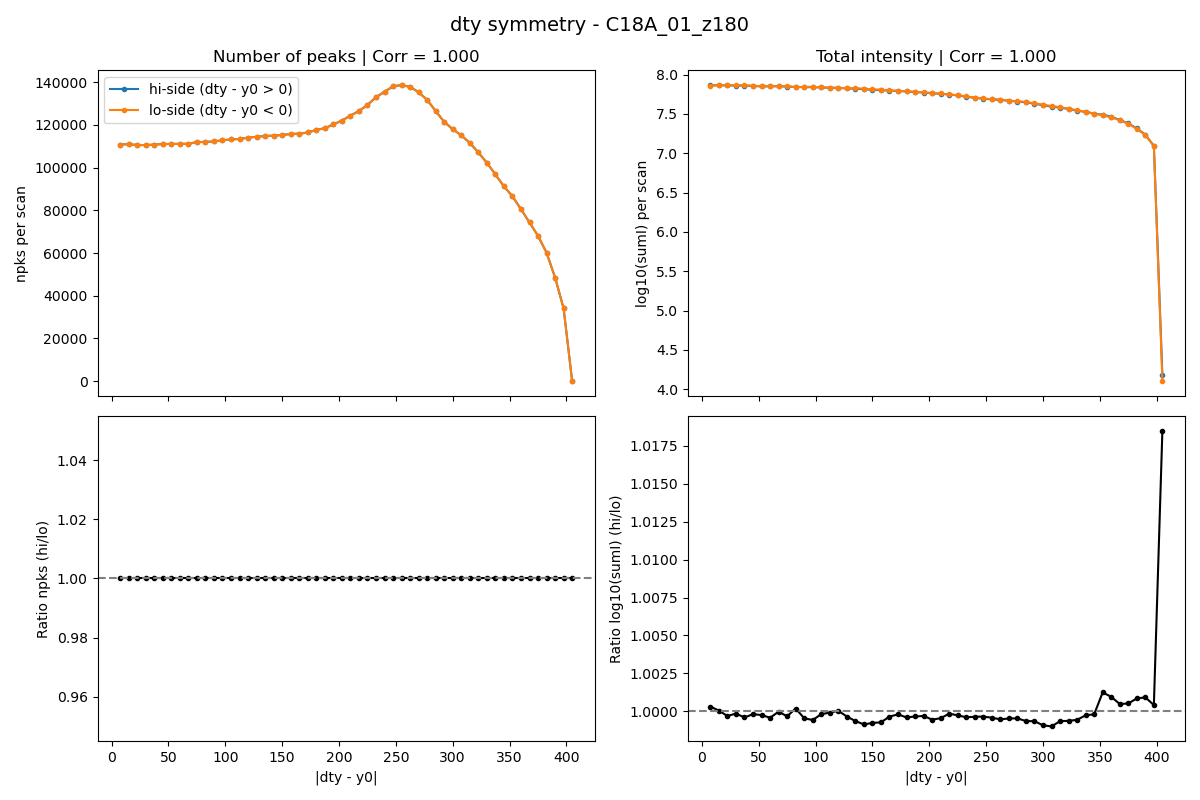

In [27]:
fig = Psub.check_symmetry()

#### 2.2 — Match omega pairs by chunks

`match_friedel_pairs_by_chunks()` orchestrates the full pipeline:

1. **Initialisation** — builds `PeakSubsets`, computes valid chunk pairs (both members must contain at least one peak)
2. **Pilot pairing** — picks a representative chunk near the centre of the sinogram and runs a quick search to auto-calibrate the search-space weights
3. **Parallel matching** — dispatches all valid chunk pairs to a pool of worker processes; each worker calls `_run_pairing` silently and returns a local result dict
4. **Merging** — local pair IDs from each chunk are offset to be globally unique and written into the `omega_pair_id` column of the master columnfile

**options**
- `chunk_type` is either `scans` or `frames` for omega-pairs.
- `extended_bin_search=True` considers also direct bin neighbours for Friedel pair matching. Works only for `scans` (and `eta_bins` for eta-pairs, see below). Slower
- `drop_unpaired=True` filters unpaired peaks out of the columnfile after merging.
- `reset_psub=True` re-initializes `PeakSubsets` in the indexer. Use `False` if you want to use pre-defined subsets. 
- `n_workers=-1` use all available cores. 

INFO:ImageD11.friedel_pairs.FriedelPairIndexer:--- MATCH FRIEDEL PAIRS [omega pairs] ---
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:--- INITIALIZATION ---
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:Chunk type for pairing: scans
INFO:ImageD11.friedel_pairs:[sort_by_sinogram] already sorted, 11918964 peaks
INFO:ImageD11.friedel_pairs:770020 non-empty frames (16960 empty).
INFO:ImageD11.friedel_pairs:109 non-empty scans  (0 empty).
INFO:ImageD11.friedel_pairs:[find_valid_subsets]  55 pairs checked in scans_LUT
  found 55 subset pairs where both members have peaks (100.00% valid).
INFO:ImageD11.friedel_pairs:[find_valid_subsets]  393490 pairs checked in frames_LUT
  found 383786 subset pairs where both members have peaks (97.53% valid).
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  55 pairs of subsets, 55 valid
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:--- SEARCH SPACE CALIBRATION [pilot pairing] ---
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  pilot search: cutoff=0.05

CPU times: user 6.82 s, sys: 2.65 s, total: 9.47 s
Wall time: 11.4 s


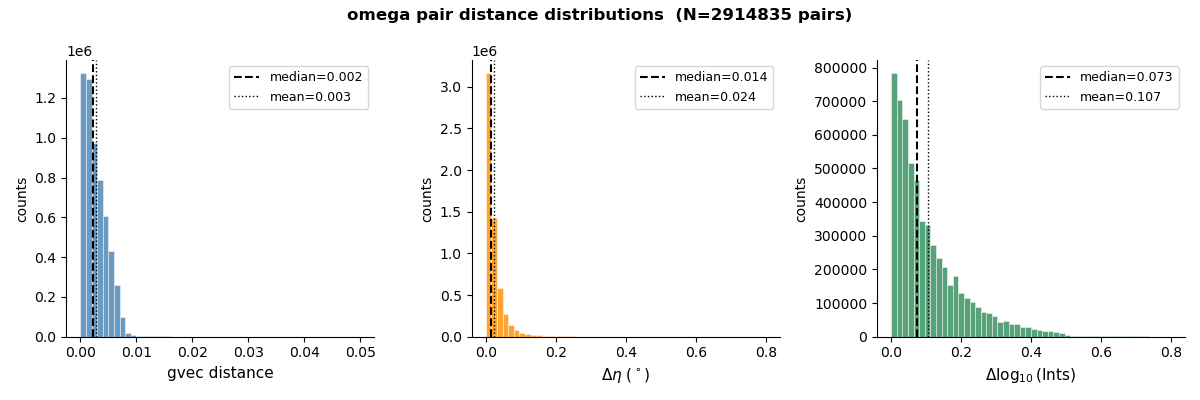

In [29]:
%%time
cf_paired = FPIndexer.match_friedel_pairs_by_chunks(chunk_type='scans',
                                                    extended_bin_search=False,
                                                    filter_mode='relaxed',
                                                    drop_unpaired=False,
                                                    reset_psub=False,
                                                    doplot=True,
                                                    n_workers=-1)

In [30]:
# get indices positions for omega and eta pairs
io1, io2 = fp.get_pairs(cf_paired, 'omega')

# sample coordinates
xs, ys  = fp.locate_omega_pairs(cf_paired, (io1,io2), ds=ds, y0=0)

hist_guess = np.histogram2d(xs+ds.y0, ys+ds.y0, bins=ds.ybinedges)[0]

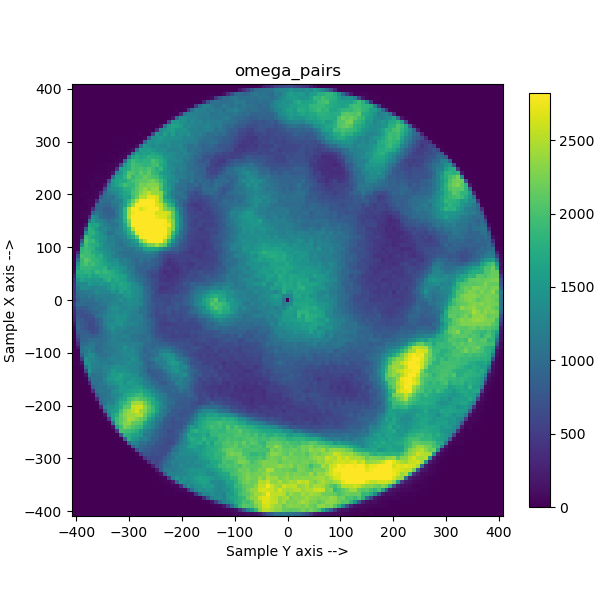

In [31]:
# plot omega hist

fig, ax = plt.subplots(1,1,layout='constrained', figsize=(6,6))
im0 = ax.pcolormesh(ds.ybinedges, ds.ybinedges, hist_guess, vmax=np.percentile(hist_guess.flatten(),99))
ax.set_aspect(1)
ax.set(title=f'omega_pairs', xlabel='Sample Y axis -->', ylabel='Sample X axis -->')
plt.colorbar(im0, ax=ax, orientation='vertical', pad=0.04, shrink=0.7)

### Eta pairs

For eta pairs, the peakfile is split into $N$ bins of equal width $\Delta\eta$ covering $[-180°, 180°)$. Mirror bins at $\eta$ and $\eta + 180°$ are paired together for the Friedel search.

This binning is arbitrary and does not correspond to physical scans or frames, which creates a boundary problem: a peak near the edge of bin $k$ may have its Friedel mate in the neighbouring bin $k\pm1$ rather than in the exact mirror bin.

To avoid this issue, use `extended_bin_search=True`:

This widens the search window to include the direct neighbours of the mirror bin, so the two subsets compared are:

$$S_\text{ref} = \text{bin}(k-1) \cup \text{bin}(k) \cup \text{bin}(k+1) \qquad S_\text{partner} = \text{bin}(k+N/2-1) \cup \text{bin}(k+N/2) \cup \text{bin}(k+N/2+1)$$

Consecutive windows overlap by one bin, so every peak appears in at least two searches:

```
bins :   | k-1 | k  | k+1 | k+2 | k+3 | k+4 | k+5 ...
          ┌────────────┐
window 1: │k-1,  k, k+1│  vs  mirror(k)
          └────────────┘
                   ┌─────────────┐
window 2:          │k+1, k+2, k+3│  vs  mirror(k+2)
                   └─────────────┘
                              ┌─────────────┐
window 3:                     │k+3, k+4, k+5│  vs  mirror(k+3)
                              └─────────────┘
```

Peaks near bin boundaries therefore have two chances to be matched. Conflicts arising from the overlap (same peak assigned to a pair in more than one window) are resolved at merging time by keeping the assignment with the smallest g-vector distance.

In [32]:
# re-initiate Peaksubset; chose the thickness of eta binning
FPIndexer.set_peak_subsets(n_eta_bins=180)
FPIndexer.sort_peak_subsets(pair_type='eta')

INFO:ImageD11.friedel_pairs.FriedelPairIndexer:--- SET PEAKSUBSETS ---
INFO:ImageD11.friedel_pairs:[get_scans_subsets] 55 pairs of dty scans (y0=0.0)


[correct_bins_for_half_scan]  y0 = 0.0000, central bin value = 0.0000, central bin id: 54, halfrange=405.0000, n_bins=109 (109 real + 0 padded).


INFO:ImageD11.friedel_pairs:[get_frames_subsets] 393490 pairs of 2D frames (y0=0.0): 3610 at y0 (omega-only), 389880 off-y0.
INFO:ImageD11.friedel_pairs:[get_eta_bins_subsets] 90 pairs of eta bins 
INFO:ImageD11.friedel_pairs:[sort_by_sinogram] sorting columnfile in eta order  –  11918964 peaks to sort, may take some time... 
INFO:ImageD11.friedel_pairs:180 non-empty bins indexed (0 bins have no peaks).
INFO:ImageD11.friedel_pairs:[find_valid_subsets]  90 pairs checked in eta_bins_LUT
  found 90 subset pairs where both members have peaks (100.00% valid).


`check_symmetry` can also be used to compare the number of peaks in mirror eta bins. The function detects automatically the type of pairing based on LUTs present in the Peaksubsets

INFO:ImageD11.friedel_pairs:[find_valid_subsets]  90 pairs checked in eta_bins_LUT
  found 90 subset pairs where both members have peaks (100.00% valid).


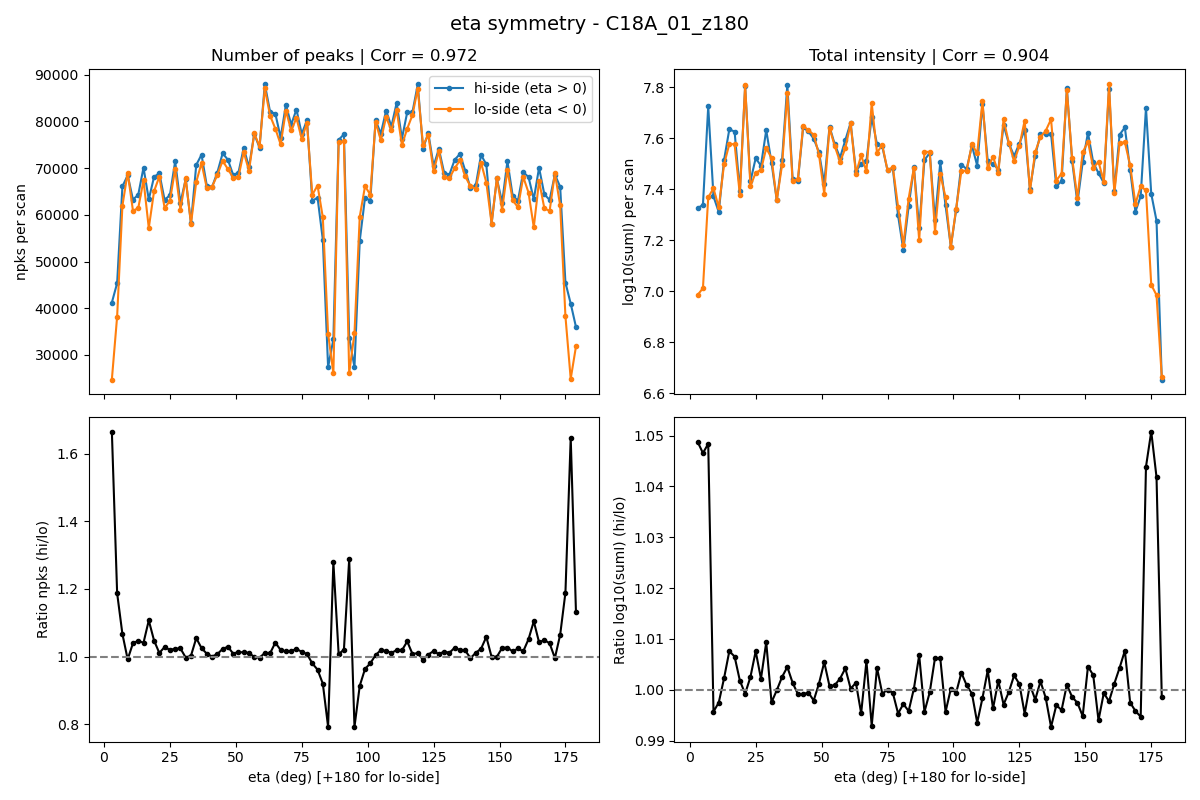

In [33]:
fig = FPIndexer.PeakSubsets.check_symmetry()

INFO:ImageD11.friedel_pairs.FriedelPairIndexer:--- MATCH FRIEDEL PAIRS [eta pairs] ---
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:--- INITIALIZATION ---
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:Chunk type for pairing: eta_bins
INFO:ImageD11.friedel_pairs:[sort_by_sinogram] peakfile already sorted – 11918964 peaks
INFO:ImageD11.friedel_pairs:180 non-empty bins indexed (0 bins have no peaks).
INFO:ImageD11.friedel_pairs:[find_valid_subsets]  90 pairs checked in eta_bins_LUT
  found 90 subset pairs where both members have peaks (100.00% valid).
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  90 pairs of subsets, 90 valid
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:--- SEARCH SPACE CALIBRATION [pilot pairing] ---
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  pilot search: cutoff=0.0567  pairs found: 32952
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:Typical (median) pair distances in non-weighted search space:
INFO:ImageD11.friedel_pairs.FriedelPairIndexer:  gvecs: 0.001

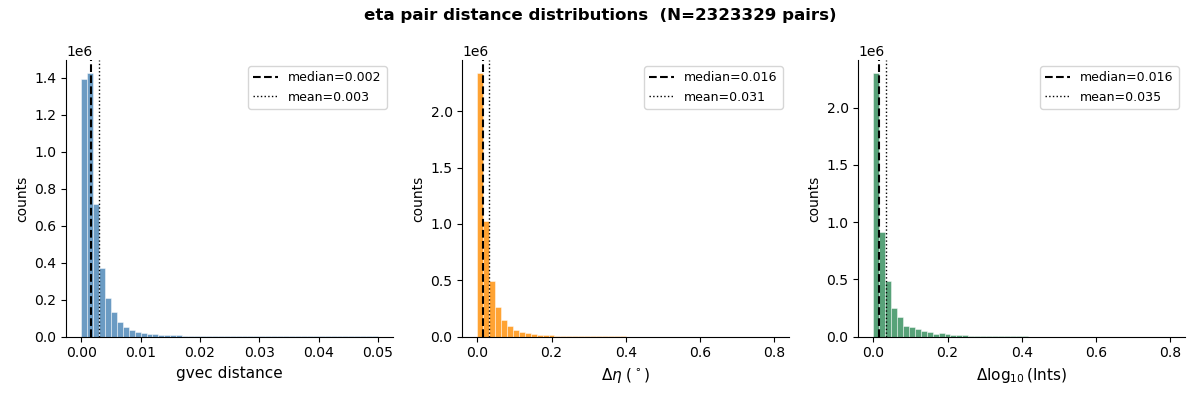

In [34]:
# match eta-pairs: use eta_bins subsets and set extended_bin_search=True to have overlap between bins 
cf_paired = FPIndexer.match_friedel_pairs_by_chunks(chunk_type='eta_bins',
                                                    drop_unpaired=False,
                                                    extended_bin_search=True,
                                                    filter_mode='relaxed',
                                                    n_workers=-1,
                                                    reset_psub=False,
                                                    doplot=True)

In [35]:
# get indices positions for omega and eta pairs
ie1, ie2 = fp.get_pairs(cf_paired, 'eta')

# sample coordinates
xs_, ys_  = fp.locate_eta_pairs(cf_paired, (ie1,ie2), ds=ds, y0=ds.y0)
hist_guess_ = np.histogram2d(xs_+ds.y0, ys_+ds.y0, bins=ds.ybinedges)[0]

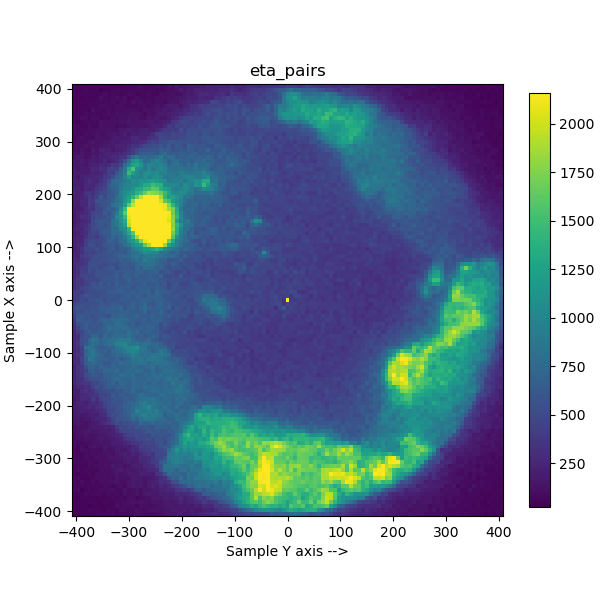

In [36]:
# plot eta hist
fig, ax = plt.subplots(1,1,layout='constrained', figsize=(6,6))
im = ax.pcolormesh(ds.ybinedges, ds.ybinedges, hist_guess_, vmax=np.percentile(hist_guess_.flatten(),99))
ax.set_aspect(1)
ax.set(title=f'eta_pairs', xlabel='Sample Y axis -->', ylabel='Sample X axis -->')
plt.colorbar(im, ax=ax, orientation='vertical', pad=0.04, shrink=0.7)



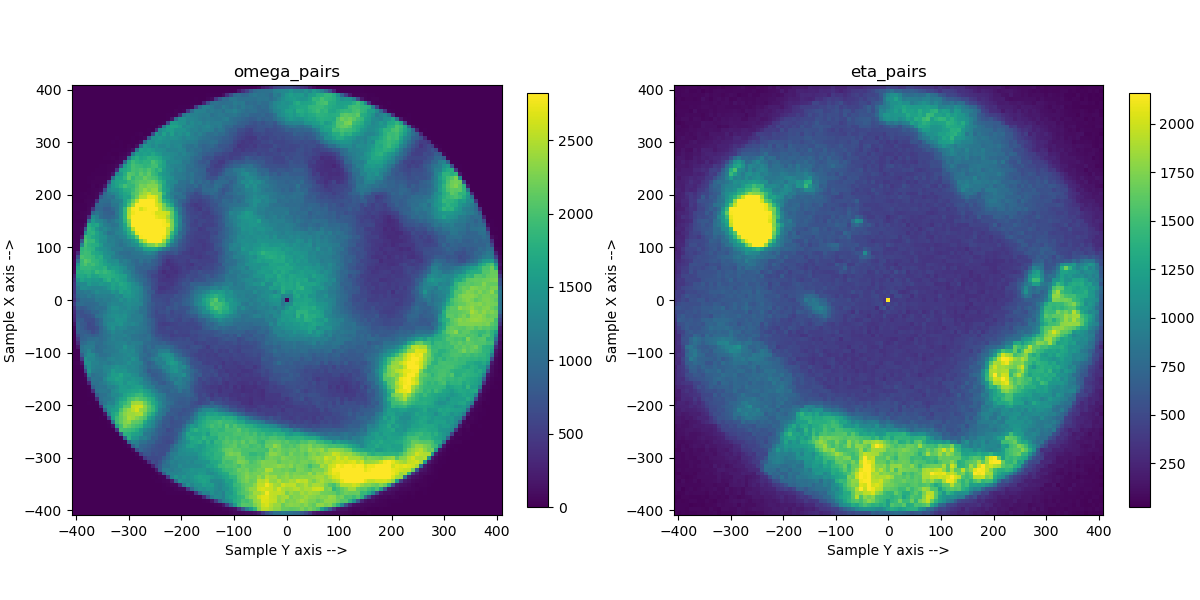

In [37]:
# plot for omega and eta hist side by side
fig, ax = plt.subplots(1,2,layout='constrained', figsize=(12,6))
im0 = ax[0].pcolormesh(ds.ybinedges, ds.ybinedges, hist_guess, vmax=np.percentile(hist_guess.flatten(),99))
ax[0].set_aspect(1)
ax[0].set(title=f'omega_pairs', xlabel='Sample Y axis -->', ylabel='Sample X axis -->')
plt.colorbar(im0, ax=ax[0], orientation='vertical', pad=0.04, shrink=0.7)


im1 = ax[1].pcolormesh(ds.ybinedges, ds.ybinedges, hist_guess_, vmax=np.percentile(hist_guess_.flatten(),99))
ax[1].set_aspect(1)
ax[1].set(title=f'eta_pairs', xlabel='Sample Y axis -->', ylabel='Sample X axis -->')
plt.colorbar(im1, ax=ax[1], orientation='vertical', pad=0.04, shrink=0.7)

Don't forget to save the peakfiles once they have been paired

In [42]:
ImageD11.columnfile.colfile_to_hdf(cf_paired, '~/cf_2d_paired.h5')